# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [19]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Library berhasil di-import')

Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [17]:
# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
df_whr = pd.read_excel('WHR26_Data_Figure_2.1.xlsx')

print(f'Shape dataset: {df_whr.shape}')

Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [6]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [7]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [8]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [9]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing' : df_whr.isnull().sum(),
    'Persentase (%)'  : (df_whr.isnull().sum() / len(df_whr) * 100).round(2)
})
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Explained by: Log GDP per capita,1097,51.84
Explained by: Social support,1097,51.84
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94
Explained by: Generosity,1097,51.84
Explained by: Perceptions of corruption,1098,51.89
Dystopia + residual,1103,52.13


**f.** Buat DataFrame `df_idn` — data Indonesia tahun 2016–2026.

In [47]:
# f. Filter data Indonesia 2006–2023
df_idn = df_whr[
    (df_whr['Country name'] == 'Indonesia') &
    (df_whr['Year'].between(2016, 2026))
].reset_index(drop=True)

print(f'Jumlah baris df_idn: {len(df_idn)}')
display(df_idn)

Jumlah baris df_idn: 10


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,87,Indonesia,5.6170,5.517000,5.718000,1.512000,1.229000,0.485000,1.043000,0.295000,0.033000,1.020000
1,2024,83,Indonesia,5.6170,5.516000,5.717000,1.288000,1.372000,0.454000,0.918000,0.323000,0.044000,1.218000
2,2023,80,Indonesia,5.5680,5.466000,5.670000,1.361000,1.184000,0.472000,0.779000,0.399000,0.055000,1.318000
3,2022,84,Indonesia,5.2770,5.161000,5.392000,1.384000,1.169000,0.314000,0.663000,0.422000,0.038000,1.288000
4,2021,87,Indonesia,5.2400,5.139000,5.341000,1.382000,0.883000,0.539000,0.620000,0.468000,0.047000,1.300000
5,2020,82,Indonesia,5.3450,5.235000,5.454000,0.954000,0.786000,0.433000,0.598000,0.541000,0.046000,1.987000
6,2019,84,Indonesia,5.2856,5.192123,5.379077,0.891721,1.154801,0.610437,0.568161,0.542647,0.038279,1.479573
7,2018,92,Indonesia,5.1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2017,96,Indonesia,5.0930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2016,81,Indonesia,5.2620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ *Jawaban Anda di sini:*

- **Kualitatif** :  
  - Nominal  :  
  - Ordinal  :  
- **Kuantitatif** :  
  - Diskrit  :  
  - Kontinu  :  

**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [11]:
# b & c. Tabel klasifikasi variabel

klasifikasi = pd.DataFrame({
    'nama_kolom' : [
        'Country name',
        'year',
        'Life Ladder',
        'Log GDP per capita',
        'Social support',
        'Healthy life expectancy at birth',
        'Freedom to make life choices',
        'Generosity',
        'Perceptions of corruption',
        'Positive affect',
        'Negative affect'
    ],
    'tipe_variabel': [
        # Isi tipe untuk setiap kolom, contoh: 'Kualitatif - Nominal'
        'Kualitatif - Nominal',   # Country name
        'Kuantitatif - Diskrit',  # year
        'Kuantitatif - Kontinu',  # Life Ladder
        'Kuantitatif - Kontinu',  # Log GDP per capita
        'Kuantitatif - Kontinu',  # Social support
        'Kuantitatif - Kontinu',  # Healthy life expectancy at birth
        'Kuantitatif - Kontinu',  # Freedom to make life choices
        'Kuantitatif - Kontinu',  # Generosity
        'Kuantitatif - Kontinu',  # Perceptions of corruption
        'Kuantitatif - Kontinu',  # Positive affect
        'Kuantitatif - Kontinu'  # Negative affect
    ],

    'alasan' : [
        # Isi alasan singkat untuk setiap kolom
        'Nama negara bersifat kategorik tanpa urutan',
        'Tahun adalah bilangan bulat yang bisa dihitung',
        'Life Ladder adalah bilangan yang dihitung dalam skala desimal',
        'Log GDP per capita adalah bilangan yang dihitung dalam skala desimal',
        'Social support adalah bilangan yang dihitung dalam skala desimal',
        'Healthy life expectancy at birth adalah bilangan yang dihitung dalam skala desimal',
        'Freedom to make life choices adalah bilangan yang dihitung dalam skala desimal',
        'Generosity adalah bilangan yang dihitung dalam skala desimal',
        'Perceptions of corruption adalah bilangan yang dihitung dalam skala desimal',
        'Positive affect adalah nilai sisa pembanding statistik yang dihitung dalam skala desimal',
        'Negative affect adalah nilai sisa pembanding statistik yang dihitung dalam skala desimal'
    ]
})

display(klasifikasi)

,nama_kolom,tipe_variabel,alasan
0,Country name,Kualitatif - Nominal,Nama negara bersifat kategorik tanpa urutan
1,year,Kuantitatif - Diskrit,Tahun adalah bilangan bulat yang bisa dihitung
2,Life Ladder,Kuantitatif - Kontinu,Life Ladder adalah bilangan yang dihitung dala...
3,Log GDP per capita,Kuantitatif - Kontinu,Log GDP per capita adalah bilangan yang dihitu...
4,Social support,Kuantitatif - Kontinu,Social support adalah bilangan yang dihitung d...
5,Healthy life expectancy at birth,Kuantitatif - Kontinu,Healthy life expectancy at birth adalah bilang...
6,Freedom to make life choices,Kuantitatif - Kontinu,Freedom to make life choices adalah bilangan y...
7,Generosity,Kuantitatif - Kontinu,Generosity adalah bilangan yang dihitung dalam...
8,Perceptions of corruption,Kuantitatif - Kontinu,Perceptions of corruption adalah bilangan yang...
9,Positive affect,Kuantitatif - Kontinu,Positive affect adalah nilai sisa pembanding s...


**d.** ✏️ *Mengapa klasifikasi variabel penting sebelum analisis statistik?*

> Jawaban Anda di sini...

---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life Ladder`.

In [12]:
# a. Central Tendency — Life Ladder
col = df_idn["Life evaluation (3-year average)"]

mean_ll   = col.mean()
median_ll = col.median()
mode_ll   = col.mode()[0]

print(f'Mean   Life Ladder : {mean_ll:.4f}')
print(f'Median Life Ladder : {median_ll:.4f}')
print(f'Mode   Life Ladder : {mode_ll:.4f}')

Mean   Life Ladder : 5.3497
Median Life Ladder : 5.2813
Mode   Life Ladder : 5.6170


**b.** ✏️ *Ukuran central tendency mana yang paling tepat untuk `Life Ladder`? Jelaskan alasannya.*

> Jawaban Anda di sini...

**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [13]:
# d. Statistik deskriptif lengkap semua kolom numerik
numeric_cols = df_idn.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

central = pd.DataFrame({
    'Mean'   : df_idn[numeric_cols].mean(),
    'Median' : df_idn[numeric_cols].median(),
    'Mode'   : df_idn[numeric_cols].mode().iloc[0],
}).round(4)

display(central)

,Mean,Median,Mode
Year,2020.5000,2020.5000,2016.0000
Rank,85.6000,84.0000,84.0000
Life evaluation (3-year average),5.3497,5.2813,5.6170
Lower whisker,5.3180,5.2350,5.1390
Upper whisker,5.5244,5.4540,5.3410
Explained by: Log GDP per capita,1.2532,1.3610,0.8917
Explained by: Social support,1.1111,1.1690,0.7860
Explained by: Healthy life expectancy,0.4725,0.4720,0.3140
Explained by: Freedom to make life choices,0.7413,0.6630,0.5682
Explained by: Generosity,0.4272,0.4220,0.2950


**e.** Bandingkan Mean `Life Ladder` Indonesia vs rata-rata global pada tahun yang tersedia.

In [46]:
# e. Perbandingan Indonesia vs global
global_mean = df_whr.groupby('Year')['Life evaluation (3-year average)'].mean()
idn_series  = df_idn.set_index('Year')['Life evaluation (3-year average)']


comparison = pd.concat([idn_series, global_mean], axis=1).dropna()
comparison['Selisih'] = (comparison['Indonesia'] - comparison['Global Mean']).round(4)

display(comparison.round(4))

# Visualisasi

KeyError: 'Indonesia'

✏️ *Interpretasi perbandingan Indonesia vs global:*

> Jawaban Anda di sini...

---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [ ]:
# a. Ukuran dispersi — Life Ladder
col = ...
data = df_idn[col]

q1  = ...
q3  = ...
iqr = ...
std = ...

dispersi = {
    'Range'                     : ...,
    'Variance'                  : ...,
    'Standard Deviation'        : ...,
    'IQR (Q3 - Q1)'             : ...,
    'Coefficient of Variation'  : ...,
}

for k, v in dispersi.items():
    print(f'{k:<30}: {v:.4f}')

**c.** ✏️ *Bandingkan Std Dev Life Ladder Indonesia vs global — apa artinya bagi konsistensi kebahagiaan Indonesia?*

> Jawaban Anda di sini...

In [ ]:
# c. Std Dev Indonesia vs global
std_idn    = ...
std_global = ...

print(f'Std Dev Indonesia : {std_idn:.4f}')
print(f'Std Dev Global    : {std_global:.4f}')

**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [ ]:
# d. IQR semua kolom numerik
iqr_all = ...
iqr_df  = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)

**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [ ]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (df_idn[numeric_cols].std() / df_idn[numeric_cols].mean() * 100)
cv_df  = cv_all.sort_values().rename('CV (%)').to_frame().round(2)
display(cv_df)

✏️ *Kolom paling stabil berdasarkan CV adalah ... karena ...*

> Jawaban Anda di sini...

## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [ ]:
# a. Deteksi outlier — metode IQR
col  = ...
data = ...

q1, q3 = ..., ...
iqr    = ...
lower  = ...
upper  = ...

outliers_iqr = ...

print(f'Batas bawah IQR : {lower:.4f}')
print(f'Batas atas  IQR : {upper:.4f}')
print(f'Jumlah outlier  : {len(outliers_iqr)}')
display(outliers_iqr[['year', col]])

**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [ ]:
# b. Deteksi outlier — metode Z-Score
z_scores = np.abs(stats.zscore(df_idn[col]))
outliers_zscore = df_idn[z_scores > 3]

print(f'Jumlah outlier Z-Score (|z|>3) : {len(outliers_zscore)}')
display(outliers_zscore[['year', col]])

print(f'\nPerbandingan:')
print(f'  IQR    : {len(outliers_iqr)} outlier')
print(f'  Z-Score: {len(outliers_zscore)} outlier')

**c.** Visualisasi outlier dengan Boxplot.

In [ ]:
# c. Boxplot — Life Ladder, Log GDP per capita, Social support
cols_box = ['Life Ladder', 'Log GDP per capita', 'Social support']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df_idn[c], ax=ax, color='steelblue', width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot — Data Indonesia (2016–2026)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**d.** ✏️ *Identifikasi tahun outlier dan jelaskan kemungkinan penyebabnya.*

> Jawaban Anda di sini...

---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

In [ ]:
# a. Histogram semua kolom numerik
n     = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_idn[col].dropna(), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Semua Variabel Numerik (Indonesia 2006–2023)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [ ]:
# b. Skewness dan Kurtosis
sk_kurt = pd.DataFrame({
    'Skewness' : df_idn[numeric_cols].skew(),
    'Kurtosis' : df_idn[numeric_cols].kurt(),
}).round(4)

display(sk_kurt)

**c.** ✏️ *Tentukan distribusi setiap kolom berdasarkan nilai skewness dan interpretasikan:*

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|-------|----------|------------------|--------------|
| Life Ladder | | | |
| *(lainnya)* | | | |

**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

In [ ]:
# d. Histogram + KDE — Life Ladder & Log GDP per capita
cols_kde = ['Life Ladder', 'Log GDP per capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, cols_kde):
    sns.histplot(df_idn[col].dropna(), bins=10, kde=True, ax=ax,
                 color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(Histogram + KDE)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi — Indonesia 2006–2023', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**e.** Bandingkan distribusi `Life Ladder` Indonesia vs global tahun 2025.

In [ ]:
# e. Indonesia vs Global — Life Ladder 2023
global_2023 = df_whr[df_whr['year'] == 2023]['Life Ladder'].dropna()
idn_2023    = df_idn[df_idn['year'] == 2023]['Life Ladder']

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(global_2023, bins=20, kde=True, ax=ax, color='steelblue',
             alpha=0.6, label='Global 2023')

if len(idn_2023) > 0:
    ax.axvline(idn_2023.values[0], color='crimson', linewidth=2.5,
               linestyle='--', label=f'Indonesia 2023: {idn_2023.values[0]:.3f}')

ax.set_title('Distribusi Life Ladder Global vs Posisi Indonesia (2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi posisi Indonesia dibandingkan distribusi global 2023:*

> Jawaban Anda di sini...

---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Ladder` Indonesia 2016–2026 dengan anotasi titik tertinggi & terendah.

KeyError: 'year'

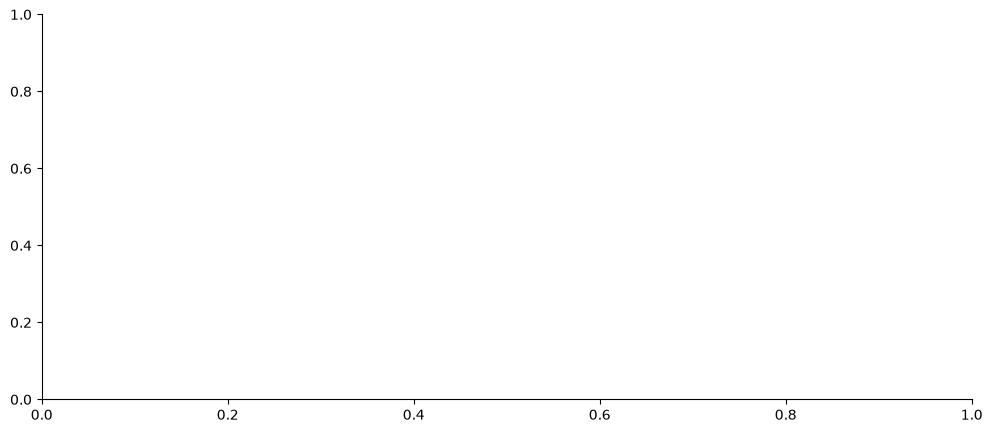

In [29]:
# a. Line Chart — Tren Life Ladder Indonesia
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_idn['year'], df_idn['Life Ladder'], marker='o',
        color='steelblue', linewidth=2, markersize=6)

# Anotasi titik tertinggi dan terendah
idx_max = df_idn['Life Ladder'].idxmax()
idx_min = df_idn['Life Ladder'].idxmin()

for idx, label, color in [(idx_max, 'Tertinggi', 'green'), (idx_min, 'Terendah', 'crimson')]:
    ax.annotate(
        f"{label}\n{df_idn.loc[idx, 'year']} ({df_idn.loc[idx, 'Life Ladder']:.3f})",
        xy=(df_idn.loc[idx, 'year'], df_idn.loc[idx, 'Life Ladder']),
        xytext=(15, 15), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_title('Tren Life Ladder Indonesia (2006–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.set_xticks(df_idn['year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**b.** Bar Chart — rata-rata `Life Ladder` negara-negara ASEAN tahun 2023.

In [ ]:
# b. Bar Chart — Life Ladder ASEAN 2023
asean = ['Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia',
         'Singapore', 'Myanmar', 'Cambodia', 'Laos', 'Brunei Darussalam']

asean_2023 = df_whr[(df_whr['Country name'].isin(asean)) &
                     (df_whr['year'] == 2023)][['Country name', 'Life Ladder']]\
             .sort_values('Life Ladder', ascending=True)

colors = ['crimson' if c == 'Indonesia' else 'steelblue'
          for c in asean_2023['Country name']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(asean_2023['Country name'], asean_2023['Life Ladder'],
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')
plt.tight_layout(); plt.show()

**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

> Jawaban Anda di sini...

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

In [ ]:
# d. Heatmap — nilai variabel per tahun
heatmap_data = df_idn.set_index('year')[numeric_cols]

# Normalisasi 0–1 agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai (normalisasi 0–1)'})
ax.set_title('Heatmap Variabel per Tahun — Indonesia (2006–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

In [ ]:
# a & b. Scatter Plot + Korelasi Pearson
pairs = [
    ('Log GDP per capita',              'Life Ladder'),
    ('Social support',                  'Life Ladder'),
    ('Healthy life expectancy at birth', 'Life Ladder'),
    ('Perceptions of corruption',        'Life Ladder'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    valid = df_idn[[x_col, y_col]].dropna()
    r, p  = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], color='steelblue', alpha=0.75, edgecolor='white', s=60)

    # Trend line
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--')

    ax.set_title(f'{x_col} vs Life Ladder\nr = {r:.3f}  (p = {p:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)

plt.suptitle('Scatter Plot: Hubungan Variabel dengan Life Ladder — Indonesia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

✏️ *Interpretasi korelasi setiap pasang variabel:*

| Pasang Variabel | r | Interpretasi |
|---|---|---|
| Log GDP vs Life Ladder | | |
| Social support vs Life Ladder | | |
| Life expectancy vs Life Ladder | | |
| Corruption vs Life Ladder | | |

**c.** Correlation Heatmap semua variabel numerik.

In [ ]:
# c. Correlation Heatmap
corr = df_idn[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Indonesia (2006–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

✏️ *Variabel yang paling berkorelasi dengan Life Ladder adalah ... dengan nilai r = ...*

> Jelaskan interpretasinya di sini...

**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

> Jawaban Anda di sini...

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ *Tuliskan minimal 5 insight dari analisis Anda:*

1. **Insight 1:** ...
2. **Insight 2:** ...
3. **Insight 3:** ...
4. **Insight 4:** ...
5. **Insight 5:** ...

**b.** Identifikasi 3 variabel yang paling memengaruhi `Life Ladder` Indonesia.

In [28]:
# b. Top 3 variabel paling berkorelasi dengan Life Ladder
corr_ll = df_idn[numeric_cols].corr()['Life Ladder']\
           .drop('Life Ladder').abs().sort_values(ascending=False)

print('Top variabel berkorelasi dengan Life Ladder:')
display(corr_ll.head(3).to_frame('|Korelasi| dengan Life Ladder').round(4))

KeyError: 'Life Ladder'

✏️ *Interpretasi 3 variabel teratas:*

> Jawaban Anda di sini...

**c.** ✏️ *Apakah tren kebahagiaan Indonesia meningkat, menurun, atau stagnan?*

> Dukung dengan data dan visualisasi di atas...

**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan rata-rata `Life Ladder`.

In [ ]:
# d. Ranking Indonesia di ASEAN (semua tahun tersedia)
asean_avg = df_whr[df_whr['Country name'].isin(asean)]\
             .groupby('Country name')['Life Ladder']\
             .mean().sort_values(ascending=False)\
             .reset_index()
asean_avg.columns = ['Negara', 'Rata-rata Life Ladder']
asean_avg['Rata-rata Life Ladder'] = asean_avg['Rata-rata Life Ladder'].round(3)
asean_avg.index += 1
asean_avg.index.name = 'Peringkat'

display(asean_avg)
rank = asean_avg[asean_avg['Negara'] == 'Indonesia'].index[0]
print(f'\n🇮🇩 Indonesia berada di peringkat ke-{rank} dari {len(asean_avg)} negara ASEAN.')

**e.** ✏️ *Rekomendasi kebijakan berdasarkan temuan analisis:*

1. **Rekomendasi 1:** *(berdasarkan variabel yang paling berkorelasi)* ...
2. **Rekomendasi 2:** *(berdasarkan tren atau perbandingan ASEAN)* ...

## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ *Tuliskan kesimpulan menyeluruh dari seluruh analisis Anda (3–5 paragraf):*

> **Paragraf 1 — Gambaran umum data:**  
> ...

> **Paragraf 2 — Temuan utama central tendency & dispersi:**  
> ...

> **Paragraf 3 — Temuan distribusi & korelasi:**  
> ...

> **Paragraf 4 — Posisi Indonesia vs global & ASEAN:**  
> ...

> **Paragraf 5 — Rekomendasi & penutup:**  
> ...